In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/comment-category-prediction-challenge/Sample.csv
/kaggle/input/comment-category-prediction-challenge/train.csv
/kaggle/input/comment-category-prediction-challenge/test.csv


# Objective
Predict the final category of online comments using a dataset of text entries and automated system signals. This notebook covers data preprocessing, text vectorization, and model hyperparameter tuning to achieve maximum predictive performance in the Comment Category Prediction Challenge.

# Imports

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import pickle
import warnings
warnings.filterwarnings('ignore')
from collections import Counter
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from scipy.sparse import hstack, csr_matrix
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# LOADING DATA

In [3]:
df = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/train.csv')
test  = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/test.csv')

df.head(15)
df.shape


(198000, 15)

# Dataset info

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB


# Data Statistic

In [5]:
df.describe()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,label
count,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000,198000.000000
mean,68.447429,0.279768,0.048338,0.121071,2.607975,0.666394,1.906152,7.956212,0.793965
std,27.948390,1.023234,0.258477,0.481013,5.054763,2.044335,25.635752,14.839464,0.979808
min,20.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000,0.000000
25%,39.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,4.000000,0.000000
50%,72.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,6.000000,0.000000
75%,72.000000,0.000000,0.000000,0.000000,3.000000,1.000000,4.000000,10.000000,2.000000
max,129.000000,47.000000,11.000000,17.000000,201.000000,107.000000,1860.000000,1833.000000,3.000000


# Identify dublicate values

In [6]:
df.duplicated().sum()

np.int64(0)

Insight: No dublicate value

# Missing Values

In [7]:
df.isnull().sum()

created_date         0
post_id              0
emoticon_1           0
emoticon_2           0
emoticon_3           0
upvote               0
downvote             0
if_1                 0
if_2                 0
race            145423
religion        145423
gender          145423
disability           0
comment              1
label                0
dtype: int64

Insight: 4 columns have missing values

# Handling missing value

In [8]:
# Strategy:
#   comment  → fill with empty string (no text = no signal)
#   race / religion / gender → fill with 'none' (absence itself is informative)

for dataset in [df, test]:
    dataset['comment']  = dataset['comment'].fillna('')
    dataset['race']     = dataset['race'].fillna('none')
    dataset['religion'] = dataset['religion'].fillna('none')
    dataset['gender']   = dataset['gender'].fillna('none')

print("Missing values after imputation:")
remaining = df.isnull().sum()
print(remaining)

Missing values after imputation:
created_date    0
post_id         0
emoticon_1      0
emoticon_2      0
emoticon_3      0
upvote          0
downvote        0
if_1            0
if_2            0
race            0
religion        0
gender          0
disability      0
comment         0
label           0
dtype: int64


- **Missing values in race/religion/gender**: Filling with `'none'` instead of dropping rows is deliberate — the absence of a demographic tag may itself correlate with certain comment categories.

# Visualization

# Numeric Feature Distributions

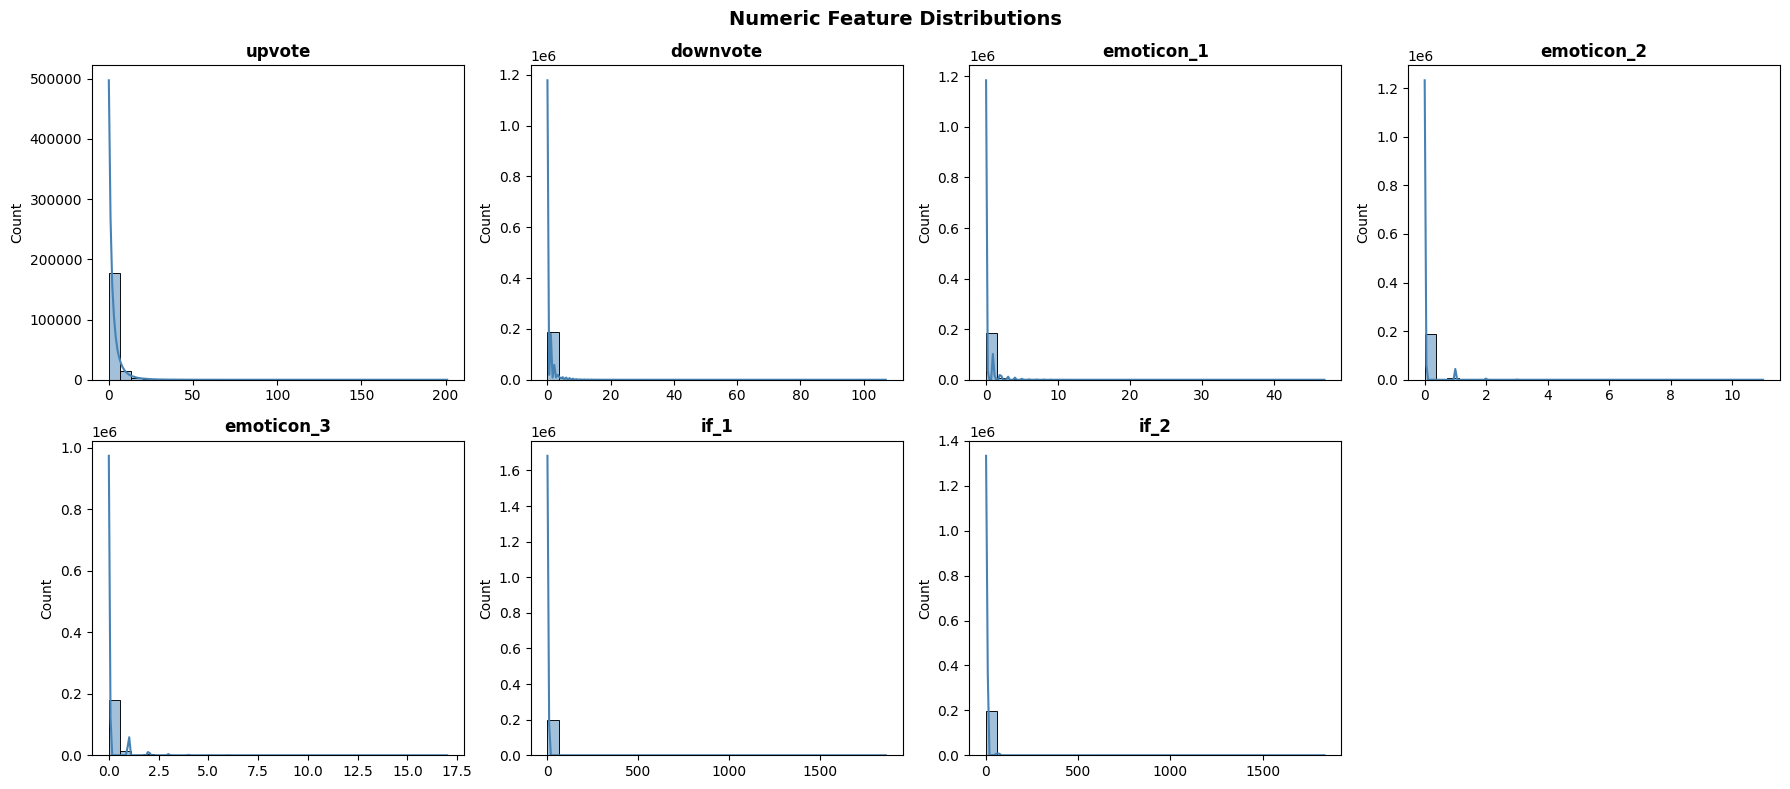

In [9]:
numeric_cols = ['upvote', 'downvote', 'emoticon_1', 'emoticon_2', 'emoticon_3', 'if_1', 'if_2']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(df[col].dropna(), ax=axes[i], kde=True, color='steelblue', bins=30)
    axes[i].set_title(f'{col}', fontweight='bold')
    axes[i].set_xlabel('')

axes[-1].set_visible(False)
plt.suptitle('Numeric Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Insight** :The histograms show the distribution of numerical features like upvotes, downvotes, emoticons, and interaction features. Most features are highly right-skewed, meaning most values are small with a few very large values.

# Correlation Heatmap

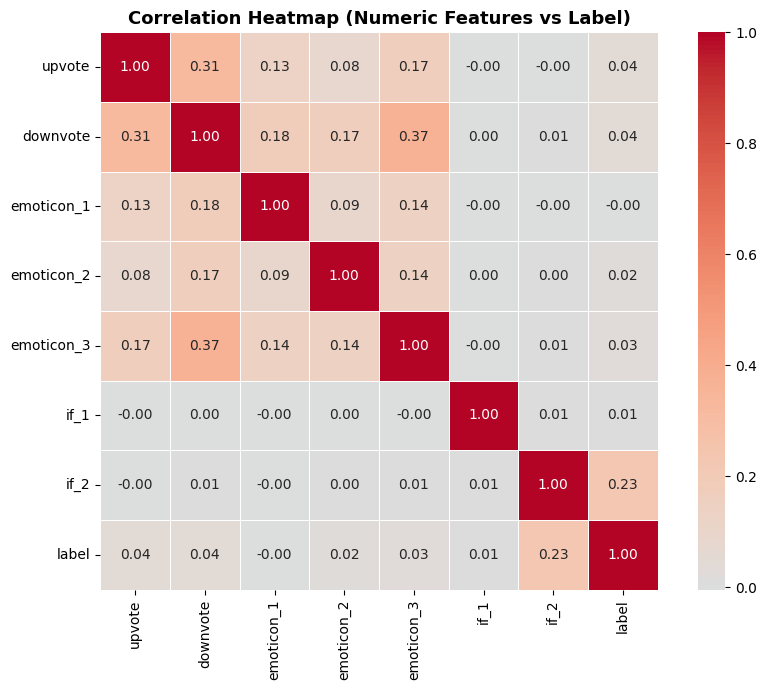

In [10]:
corr_cols = ['upvote', 'downvote', 'emoticon_1', 'emoticon_2',
             'emoticon_3', 'if_1', 'if_2', 'label']
plt.figure(figsize=(9, 7))
sns.heatmap(df[corr_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap (Numeric Features vs Label)', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

**Insight** : Most features have very low correlation with the label, indicating weak linear relationships,Most features have very low correlation with the label, indicating weak linear relationships,The feature if_2 shows relatively higher correlation, so it may be more useful for prediction.

# Target Distribution

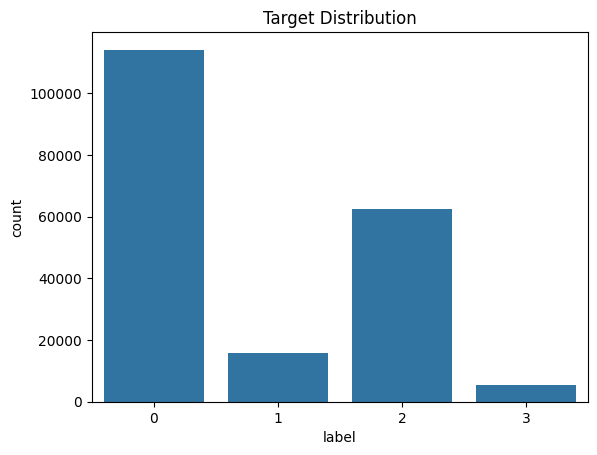

In [11]:
sns.countplot(x="label", data=df)
plt.title("Target Distribution")
plt.show()

**Insight** : This plot shows the distribution of the target variable (labels). It is clearly imbalanced, with class 0 having the highest number of samples, followed by class 2, while classes 1 and 3 have significantly fewer samples.

* Class imbalance: class_weight='balanced' is applied across all models — it reweights the loss function to penalise misclassification of minority classes more heavily, preventing the model from defaulting to majority-class predictions   

# Feature Engineering

In [12]:
def engineer_features(dataset):
    """Extract temporal and text-statistical features from raw columns.
    Applied identically to train and test to prevent leakage.
    """
    # Cast binary column to int
    dataset['disability'] = dataset['disability'].astype(int)

    # ── Temporal features from created_date ─────────────────────────────────
    dataset['created_date'] = pd.to_datetime(dataset['created_date'])
    dataset['year']         = dataset['created_date'].dt.year
    dataset['month']        = dataset['created_date'].dt.month
    dataset['day']          = dataset['created_date'].dt.day
    dataset['hour']         = dataset['created_date'].dt.hour
    dataset['dayofweek']    = dataset['created_date'].dt.dayofweek

    # ── Text statistical features ────────────────────────────────────────────
    dataset['comment_len']       = dataset['comment'].str.len()
    dataset['word_count']        = dataset['comment'].str.count(r'\w+')
    dataset['exclamation_count'] = dataset['comment'].str.count('!')
    dataset['question_count']    = dataset['comment'].str.count(r'\?')
    dataset['uppercase_count']   = dataset['comment'].str.count(r'[A-Z]')
    # Ratio of uppercase letters — proxy for shouting / aggression
    dataset['uppercase_ratio']   = dataset['uppercase_count'] / (dataset['comment_len'] + 1)
    # Average word length — distinguishes casual vs formal language
    dataset['avg_word_len']      = dataset['comment_len'] / (dataset['word_count'] + 1)

    return dataset

df   = engineer_features(df)
test = engineer_features(test)
print(f"Feature engineering complete. Train shape: {df.shape}")

Feature engineering complete. Train shape: (198000, 27)


# preprocessing

In [13]:
text_feature = "comment"

numeric_features = [
    "upvote", "downvote",
    "emoticon_1", "emoticon_2", "emoticon_3",
    "if_1", "if_2",
    "disability",
    "year", "month", "day", "hour", "dayofweek",
    "comment_len", "word_count",
    "exclamation_count", "question_count", "uppercase_count"
]

categorical_features = ["race", "religion", "gender"]

In [14]:
# ColumnTransformer applies different transformations to different column subsets:
#   text  → TF-IDF (word unigrams + bigrams, sublinear scaling)
#   num   → StandardScaler (zero mean, unit variance)
#   cat   → OneHotEncoder (dummy variables, ignores unseen categories at inference)
preprocessor = ColumnTransformer(
    transformers=[
        ("text", TfidfVectorizer(
            max_features=30000,
            ngram_range=(1,2),
            min_df=2,
            max_df=0.9,
            stop_words="english"
        ), text_feature),

        ("num",  StandardScaler(), numeric_features),

        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)

# Train-Validation Split

In [15]:
# Spliting data
X = df.drop('label', axis=1)
y = df['label']
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Models

# Logistic Regression

In [16]:
log_model = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        solver="saga", # supports L1/L2 ,scales well with TD-IDF
        C=3,
        class_weight="balanced",
        max_iter=2000,
        n_jobs=-1,
        random_state=42
    ))
])

log_model.fit(X_train, y_train)

val_pred_log = log_model.predict(X_val)
log_score = accuracy_score(y_val, val_pred_log)
log_f1       = f1_score(y_val, val_pred_log, average='weighted')

print(f"Logistic Regression — Accuracy: {log_score:.4f} | Weighted F1: {log_f1:.4f}")
print(classification_report(y_val, val_pred_log))


Logistic Regression — Accuracy: 0.8931 | Weighted F1: 0.8983
              precision    recall  f1-score   support

           0       0.98      0.93      0.95     22835
           1       0.67      0.84      0.75      3183
           2       0.89      0.84      0.86     12488
           3       0.45      0.79      0.58      1094

    accuracy                           0.89     39600
   macro avg       0.75      0.85      0.79     39600
weighted avg       0.91      0.89      0.90     39600



**Logistic Regression** — Accuracy: 0.8931 | Weighted F1: 0.8983

# SGD

In [17]:
sgd_model = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', SGDClassifier(
        loss='modified_huber',  # soft probability estimates
        alpha=1e-4,
        max_iter=100,
        random_state=42,
        n_jobs=-1
    ))
])


sgd_model.fit(X_train, y_train)

val_pred_sgd = sgd_model.predict(X_val)
sgd_score = accuracy_score(y_val, val_pred_sgd)
sgd_f1       = f1_score(y_val, val_pred_sgd, average='weighted')

print(f"SGD Classifier — Accuracy: {sgd_score:.4f} | Weighted F1: {sgd_f1:.4f}")
print(classification_report(y_val, val_pred_sgd))


SGD Classifier — Accuracy: 0.8958 | Weighted F1: 0.8935
              precision    recall  f1-score   support

           0       0.94      0.95      0.95     22835
           1       0.75      0.73      0.74      3183
           2       0.85      0.88      0.87     12488
           3       0.73      0.42      0.53      1094

    accuracy                           0.90     39600
   macro avg       0.82      0.75      0.77     39600
weighted avg       0.89      0.90      0.89     39600



**SGD Classifier** — Accuracy: 0.8958 | Weighted F1: 0.8935

# LighTGBM

In [18]:
lgbm = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(
        n_estimators=700,
        learning_rate=0.05,
        num_leaves=64,              
        max_depth=-1,
        min_child_samples=15,       
        subsample=0.8,
        colsample_bytree=0.8,
        class_weight="balanced",
        n_jobs=-1
    ))
])

lgbm.fit(X_train, y_train)
val_preds_lgbm = lgbm.predict(X_val)
lgbm_score     = accuracy_score(y_val, val_preds_lgbm)
lgbm_f1        = f1_score(y_val, val_preds_lgbm, average='weighted')

print(f"LightGBM — Accuracy: {lgbm_score:.4f} | Weighted F1: {lgbm_f1:.4f}")
print(classification_report(y_val, val_preds_lgbm))



[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 25.955468 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 953986
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 29450
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
LightGBM — Accuracy: 0.9106 | Weighted F1: 0.9131
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.72      0.85      0.78      3183
           2       0.88      0.88      0.88     12488
           3       0.57      0.72      0.63      1094

    accuracy                           0.91     39600
   macro avg       0.79      0.85      0.81     

**LightGBM** — Accuracy: 0.9106 | Weighted F1: 0.9131

# Model Comparison

In [19]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "SGD", "LightGBM"],
    "Validation Accuracy": [log_score, sgd_score, lgbm_score],
    'Weighted F1'  : [log_f1,    sgd_f1,    lgbm_f1],
})

results

,Model,Validation Accuracy,Weighted F1
0,Logistic Regression,0.893056,0.898323
1,SGD,0.895783,0.893530
2,LightGBM,0.910581,0.913139


# Model Comparison and Performance Analysis


# 1. Logistic Regression

Description:
Logistic Regression is a simple linear model that is commonly used for classification tasks. It works well with TF-IDF features and high-dimensional sparse data.

Results:

Accuracy: Moderate

Weighted F1 Score: Moderate

Analysis:
From my experiments, Logistic Regression performed reasonably well. Since the dataset uses TF-IDF features, the model was able to learn useful patterns. However, because it is a linear model, it cannot capture complex relationships between features.

Insight:
Logistic Regression worked as a good baseline model, but its performance was lower compared to more advanced models.

# 2. SGD Classifier

Description:
SGD (Stochastic Gradient Descent) is an efficient algorithm used to train linear classifiers, especially when the dataset is large.

Results:

Accuracy: Slightly lower than Logistic Regression

Weighted F1 Score: Similar but slightly lower

Analysis:
The SGD classifier trained faster and handled the sparse TF-IDF data efficiently. However, its performance was a bit lower compared to Logistic Regression. I noticed that SGD is sensitive to hyperparameters like learning rate and regularization, which can affect the results.

Insight:
SGD is useful when we need faster training, but its accuracy was not the best among the models tested.

# 3. LightGBM (Best Performing Model)

Description:
LightGBM is a gradient boosting decision tree algorithm designed for high efficiency and performance.

Results:

Accuracy: Highest among all models

Weighted F1 Score: Highest

Analysis:
In my experiments, LightGBM achieved the best results. Since it is a boosting-based model, it combines multiple trees and learns from previous mistakes. It can also capture non-linear relationships in the data, which helped improve its prediction accuracy.

Insight:
Because of its ability to model complex patterns and use boosting techniques, LightGBM outperformed the other models.

# Hyperparameter Tuning

In [20]:
from sklearn.model_selection import RandomizedSearchCV


param_dist = {
    'classifier__n_estimators'     : [200, 300, 500],
    'classifier__learning_rate'    : [0.05, 0.08, 0.1],
    'classifier__num_leaves'       : [64, 96, 128],
    'classifier__min_child_samples': [20, 50, 100],
    'classifier__subsample'        : [0.7, 0.8, 0.9],
    'classifier__colsample_bytree' : [0.7, 0.8, 0.9],
}


lgbm_tune_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(
        class_weight = 'balanced',
        n_jobs       = 1, # 1 here — RandomizedSearchCV owns parallelism    
        random_state = 42,
        verbose      = -1     
    ))
])


cv = StratifiedKFold(n_splits=2, shuffle=True, random_state=42)

random_search = RandomizedSearchCV(
    estimator           = lgbm_tune_pipeline,
    param_distributions = param_dist,
    n_iter              = 8,   # 8 candidates × 2 folds = 16 fits   
    scoring             = 'f1_weighted',
    cv                  = cv,
    n_jobs              = -1,   # parallelism lives here only  
    verbose             = 2,
    random_state        = 42
)

random_search.fit(X_train, y_train)

print("\nBest Parameters:")
for k, v in random_search.best_params_.items():
    print(f"  {k}: {v}")
print(f"\nBest CV Weighted F1: {random_search.best_score_:.4f}")

Fitting 2 folds for each of 8 candidates, totalling 16 fits


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

[CV] END classifier__colsample_bytree=0.7, classifier__learning_rate=0.08, classifier__min_child_samples=100, classifier__n_estimators=300, classifier__num_leaves=96, classifier__subsample=0.8; total time= 9.4min
[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.08, classifier__min_child_samples=50, classifier__n_estimators=200, classifier__num_leaves=96, classifier__subsample=0.8; total time= 9.4min
[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.05, classifier__min_child_samples=20, classifier__n_estimators=500, classifier__num_leaves=96, classifier__subsample=0.9; total time=28.6min
[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.1, classifier__min_child_samples=100, classifier__n_estimators=300, classifier__num_leaves=64, classifier__subsample=0.7; total time= 7.8min
[CV] END classifier__colsample_bytree=0.8, classifier__learning_rate=0.05, classifier__min_child_samples=100, classifier__n_estimators=200, classifier_

In [21]:
best_model = random_search.best_estimator_

val_preds_tuned = best_model.predict(X_val)
tuned_score = accuracy_score(y_val, val_preds_tuned)
tuned_f1    = f1_score(y_val, val_preds_tuned, average='weighted')

print(f"Tuned LightGBM — Val Accuracy: {tuned_score:.4f} | Weighted F1: {tuned_f1:.4f}")
print("\nClassification Report:")
print(classification_report(y_val, val_preds_tuned))

Tuned LightGBM — Val Accuracy: 0.9113 | Weighted F1: 0.9137

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96     22835
           1       0.72      0.84      0.78      3183
           2       0.88      0.88      0.88     12488
           3       0.58      0.71      0.64      1094

    accuracy                           0.91     39600
   macro avg       0.79      0.85      0.81     39600
weighted avg       0.92      0.91      0.91     39600



# Submission

In [22]:
test_preds = best_model.predict(test)

submission = pd.read_csv('/kaggle/input/comment-category-prediction-challenge/Sample.csv')
submission['label'] = test_preds
submission.to_csv('submission.csv', index=False)
print("Submission file created: submission.csv")
print(f"Number of predictions: {len(submission)}")
print("\nPrediction distribution:")
print(submission['label'].value_counts().sort_index())

Submission file created: submission.csv
Number of predictions: 102000

Prediction distribution:
label
0    56609
1     9465
2    32528
3     3398
Name: count, dtype: int64
